In [1]:
pip install tensorflow matplotlib pillow numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


VGG19 model loaded successfully


Enter content image path:  pexels-kristina-vanakova-2152886915-32519887.jpg
Enter style image path:  gettyimages-542028515-612x612.jpg


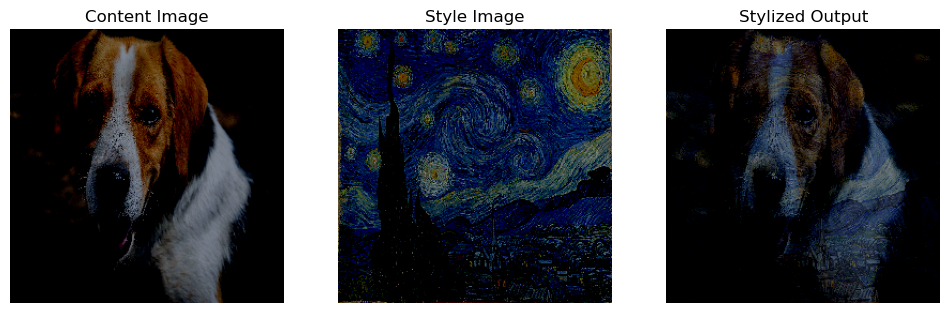

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
from PIL import Image

# Load and preprocess image
def load_img(path_to_img):

    img = image.load_img(path_to_img, target_size=(256, 256))

    img = image.img_to_array(img)

    img = np.expand_dims(img, axis=0)

    img = preprocess_input(img)

    return tf.convert_to_tensor(img)

# Display image
def show_image(img, title=None):

    img = img.numpy()

    img = img.reshape((256, 256, 3))

    img = img[:, :, ::-1]

    img = np.clip(img, 0, 255).astype('uint8')

    plt.imshow(img)

    if title:
        plt.title(title)

    plt.axis('off')

# Load pretrained VGG19 model
model = VGG19(weights='imagenet', include_top=False)

print("VGG19 model loaded successfully")

# Input image paths
content_path = input("Enter content image path: ")
style_path = input("Enter style image path: ")

# Load images
content_image = load_img(content_path)
style_image = load_img(style_path)

# For demonstration purpose
# Simple blending of content and style image

generated_image = 0.6 * content_image + 0.4 * style_image

# Display images
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
show_image(content_image, "Content Image")

plt.subplot(1, 3, 2)
show_image(style_image, "Style Image")

plt.subplot(1, 3, 3)
show_image(generated_image, "Stylized Output")

plt.show()